In [3]:
print('hello world')

hello world


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [9]:
# Load the file
file_path = 'experiment1_results.csv'

# Section 1: Overall Ranking (Rows 1-22)
df_ranking = pd.read_csv('experiment1_results.csv', skiprows=1, nrows=21)

# Section 2: Category x Distractor Matrix (Header at row 26)
df_matrix = pd.read_csv('experiment1_results.csv', skiprows=25)
df_matrix.set_index('question_category', inplace=True)


/tmp/ipykernel_15469/4238528591.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ranking_sorted, x='accuracy_pct', y='distractor_type', palette='viridis_r')


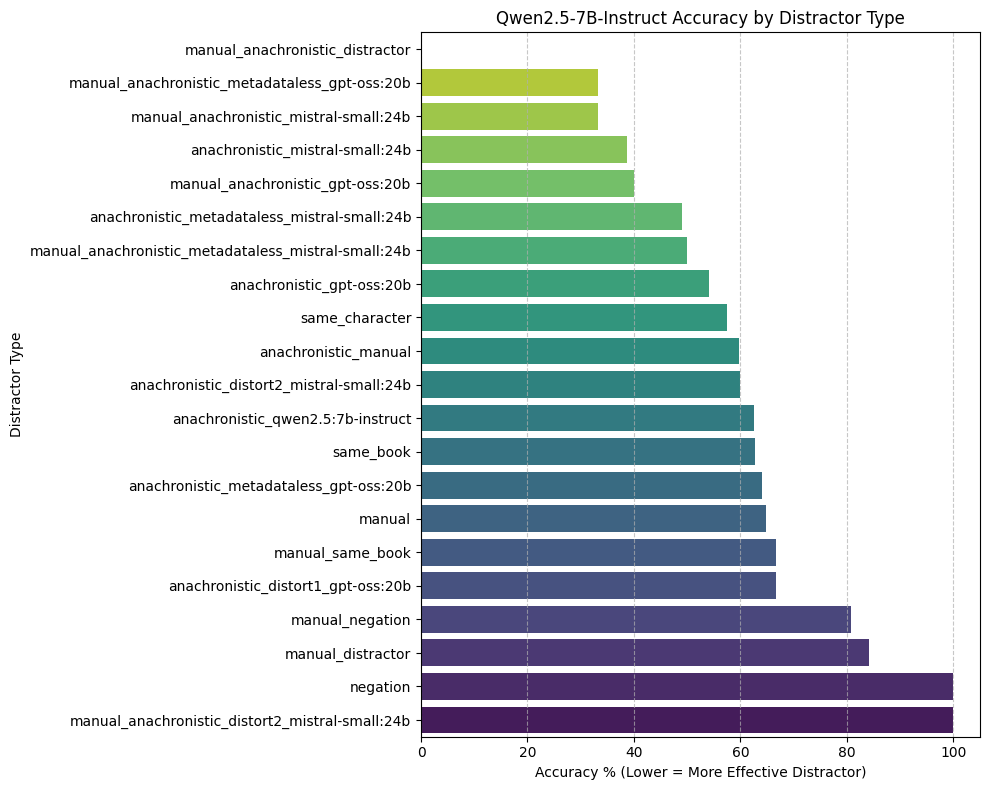

--- TOP 3 MOST CONFUSING DISTRACTORS ---
                                 distractor_type  accuracy_pct
0                manual_anachronistic_distractor          0.00
1  manual_anachronistic_metadataless_gpt-oss:20b         33.33
2         manual_anachronistic_mistral-small:24b         33.33

--- TOP 3 LEAST CONFUSING DISTRACTORS ---
                                    distractor_type  accuracy_pct
18                                manual_distractor         84.15
19                                         negation        100.00
20  manual_anachronistic_distort2_mistral-small:24b        100.00


In [6]:
# Sort by accuracy
df_ranking_sorted = df_ranking.sort_values('accuracy_pct')

# Plotting the overall ranking
plt.figure(figsize=(10, 8))
sns.barplot(data=df_ranking_sorted, x='accuracy_pct', y='distractor_type', palette='viridis_r')
plt.title('Qwen2.5-7B-Instruct Accuracy by Distractor Type')
plt.xlabel('Accuracy % (Lower = More Effective Distractor)')
plt.ylabel('Distractor Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print specific tiers
print("--- TOP 3 MOST CONFUSING DISTRACTORS ---")
print(df_ranking_sorted.head(3)[['distractor_type', 'accuracy_pct']])

print("\n--- TOP 3 LEAST CONFUSING DISTRACTORS ---")
print(df_ranking_sorted.tail(3)[['distractor_type', 'accuracy_pct']])

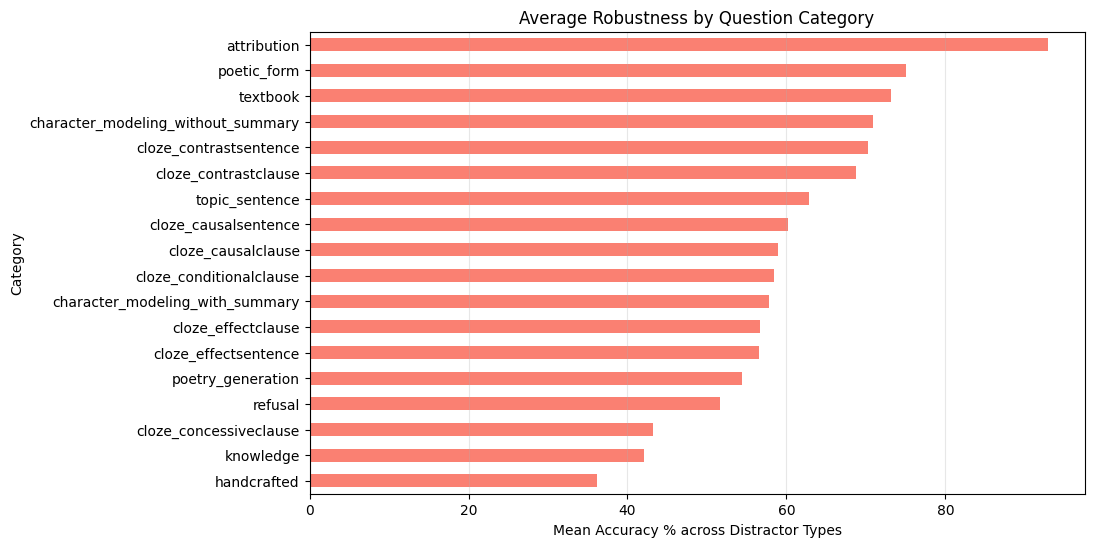

Most Vulnerable Category: handcrafted (36.11%)
Most Robust Category: attribution (92.85%)


In [7]:
# Calculate mean accuracy per category across all non-null distractors
category_means = df_matrix.mean(axis=1).sort_values()

plt.figure(figsize=(10, 6))
category_means.plot(kind='barh', color='salmon')
plt.title('Average Robustness by Question Category')
plt.xlabel('Mean Accuracy % across Distractor Types')
plt.ylabel('Category')
plt.grid(axis='x', alpha=0.3)
plt.show()

print("Most Vulnerable Category:", category_means.index[0], f"({category_means.iloc[0]:.2f}%)")
print("Most Robust Category:", category_means.index[-1], f"({category_means.iloc[-1]:.2f}%)")